# TARP Power BI Dashboard Report

**Project:** Traffic Accident Risk Prediction (TARP)  
**Dashboard tool:** Power BI  
**Focus:** Executive crash overview, crash severity, hotspot patterns, weather conditions, mobility indicators and model results

This notebook report documents the final Power BI dashboard pages and explains the purpose of each visual. The dashboard was designed to make the accident risk analysis easier to review, present and discuss. Each section below explains the dashboard page, the fields used in the visuals and the key insights shown by the final dashboard output.

## 1. Report Overview

The dashboard is organised into six pages:

1. **Executive Overview:** summarises crash totals, fatal crashes, serious injury crashes, rainy-day crashes, rush-hour crashes, yearly trends, severity distribution, Time period patterns and weekday versus weekend crashes.
2. **Crash Severity Overview:** compares crash severity by region, speed zone, road geometry and accident type.
3. **Crash Hotspot Patterns:** identifies where crashes are concentrated across Victoria and which LGAs have higher crash volume or average severity.
4. **Weather Insights:** explores how rainfall, temperature, hot days and wind direction relate to crash patterns.
5. **Mobility Insights:** examines road-user involvement, pedestrian density, bicycle density and urban classification.
6. **Model Results:** summarises the machine-learning model comparison, class-wise model performance and feature importance.

## 2. Dashboard Link

In [1]:
from IPython.display import HTML, display

POWERBI_EMBED_URL = (
    "https://app.powerbi.com/reportEmbed?"
    "reportId=1393ef83-32c7-42f1-8fa7-c5129b1d859e"
    "&autoAuth=true"
    "&ctid=d02378ec-1688-46d5-8540-1c28b5f470f6"
)

def show_powerbi_report(width="100%", height=720):
    """Display embedded Power BI report in a notebook."""
    iframe = f"""
    <iframe
        title="Power BI Report"
        width="{width}"
        height="{height}"
        src="{POWERBI_EMBED_URL}"
        frameborder="0"
        allowFullScreen="true">
    </iframe>
    """
    display(HTML(iframe))

show_powerbi_report()

## 3. Dashboard Data and Measures

The dashboard uses the validated modelling dataset and model output CSV files generated during the project. The main crash dataset contains crash, location, time, weather, road, severity and mobility-related fields. The model-result page uses separate model-output files for model comparison, class-wise performance and feature importance.

| Area | Example fields used |
|---|---|
| Crash identification | `ACCIDENT_NO` |
| Target variable | `SEVERITY` |
| Location | `DTP_REGION`, `LGA_NAME`, `LATITUDE`, `LONGITUDE` |
| Time | `year_x`, `month_name`, `day_of_week`, `hour_of_day`, `time_period` |
| Road conditions | `SPEED_ZONE`, `ROAD_GEOMETRY`, `ACCIDENT_TYPE`, `ROAD_TYPE` |
| Weather | `Min temperature (°C)`, `Max temperature (°C)`, `Total Rainfall (mm)`, `rain_indicator`, `is_hot_day`, `Direction of wind` |
| Mobility | `pedestrian_density`, `bicycle_density`, `DRIVER`, `PASSENGER`, `MOTORCYCLIST`, `BICYCLIST`, `PEDESTRIAN` |
| Model outputs | `Accuracy`, `Precision`, `Recall`, `F1-score`, `Feature`, `Importance` |

The key measure used throughout the dashboard is **Total Crashes**, usually calculated as a count of accident records. Other pages use derived measures such as average severity score, rainfall totals, average temperature, road-user counts and model-performance metrics.

# Page 1 Executive Overview

## Page purpose

The Executive Overview page provides a high-level summary of the accident risk dashboard. It combines key performance indicators with trend, severity, timing and weekday/weekend visuals so the main crash patterns can be understood quickly.

**Main slicer used:** `year_x`  
**Main fields and measures:** `ACCIDENT_NO`, `SEVERITY`, `year_x`, `time_period`, `week_part`, `rain_indicator`, `rush_hour_flag`, `Total Crashes measure`

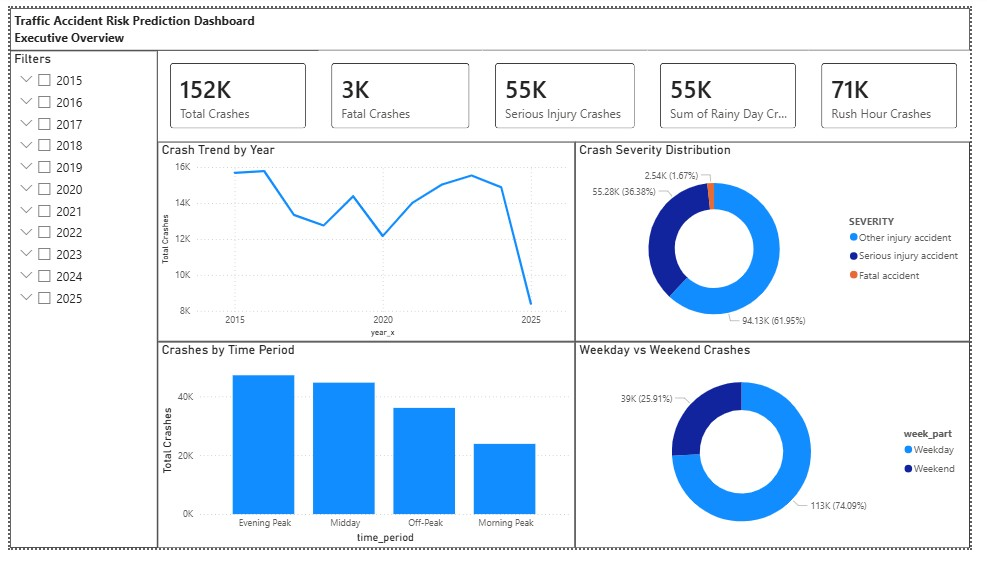

In [2]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/ExecutiveOverview.jpg"
display(Image(filename=image_path))

## Visual 1.1 Executive KPI Cards

**Visual type:** KPI cards  
**Measures used:**

- Total Crashes
- Fatal Crashes
- Serious Injury Crashes
- Sum of Rainy Day Crashes
- Rush Hour Crashes

**Overview**

The KPI cards summarise the key dashboard totals at the top of the page. They show the overall crash count and highlight the most important safety categories, including fatal crashes, serious injury crashes, rainy-day crashes and rush-hour crashes.

**Insights**

The dashboard shows **152K total crashes**, **3K fatal crashes**, **55K serious injury crashes**, **55K rainy-day crashes** and **71K rush-hour crashes**. These indicators provide a quick overview of the crash scale and the major risk categories in the dataset.

**Relevance**

The KPI cards give decision makers an immediate summary before reviewing detailed charts. They also make it easier to compare the main crash categories across selected years.

## Visual 1.2 Crash Trend by Year

**Visual type:** Line chart  
**Columns/measures used:**

- `year_x`
- `Total Crashes measure`

**Overview**

The line chart shows how total crashes changed across years. It helps identify whether crash volume increased, decreased, or fluctuated over time.

**Insights**

The trend remains relatively high across most years, with visible changes between 2015 and 2024 and a sharp drop in 2025 due to the partial-year selection or available records for that year.

**Relevance**

A yearly trend is important for understanding whether crash risk is stable or changing. It also helps separate long-term patterns from single year variation.

## Visual 1.3 Crash Severity Distribution

**Visual type:** Donut chart  
**Columns/measures used:**

- `SEVERITY`
- `Total Crashes measure`

**Overview**

The donut chart shows the proportion of crashes by severity category.

**Insights**

Most crashes are classified as **Other injury accident**, followed by **Serious injury accident**. **Fatal accident** forms the smallest share of the total.

**Relevance**

Severity distribution gives context to the dashboard totals. It shows that fatal crashes are comparatively rare, while injury crashes make up the main volume of the dataset.

## Visual 1.4 Crashes by Time Period

**Visual type:** Column chart  
**Columns/measures used:**

- `time_period`
- `Total Crashes measure`

**Overview**

The column chart compares crash volume across major parts of the day, including morning peak, midday, off-peak and evening peak periods.

**Insights**

The highest crash volume appears during **Evening Peak**, followed by **Midday** and **Off-Peak**. **Morning Peak** has the lowest count among the visible time periods.

**Relevance**

Time period analysis supports road-safety planning by showing when crashes are most concentrated. This helps connect crash risk with travel demand and traffic congestion.

## Visual 1.5 Weekday vs Weekend Crashes

**Visual type:** Donut chart  
**Columns/measures used:**

- `week_part`
- `Total Crashes measure`

**Overview**

The donut chart compares crash counts between weekdays and weekends.

**Insights**

Weekdays account for the majority of crashes, while weekends represent a smaller share. This pattern is consistent with higher weekday commuting and business related travel activity.

**Relevance**

The weekday/weekend split helps identify whether crash risk is mainly linked with weekday travel demand or weekend activity patterns.

# Page 2 Crash Severity Overview

## Page purpose

The Crash Severity Overview page provides a structured view of how crash severity changes across regions, speed zones, road geometry and accident types. This page is useful because it quickly shows which parts of the transport network experience the highest crash volume and which conditions are linked with more severe outcomes.

**Main slicer used:** `year_x`  
**Main severity grouping:** `SEVERITY`



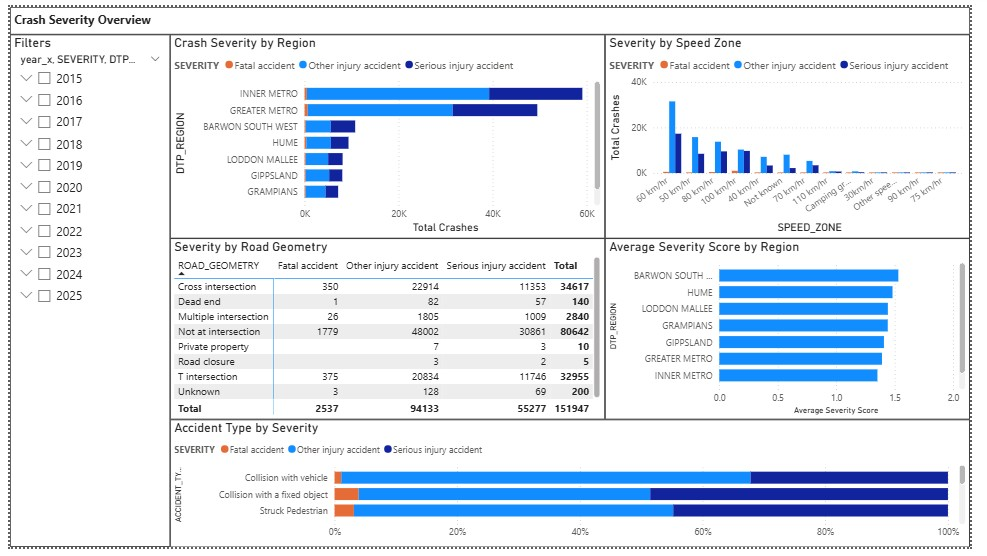

In [3]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/SeverityOverview.jpg"
display(Image(filename=image_path))

## Visual 2.1 Crash Severity by Region

**Visual type:** Stacked horizontal bar chart  
**Columns/measures used:**

- `DTP_REGION`
- `SEVERITY`
- `ACCIDENT_NO or Total Crashes measure`

**Overview**

This graph compares the number of crashes across transport regions, separated by crash severity. Each bar represents a region and the coloured segments show how many crashes fall into each severity group.

**Insights**

The output shows that **Inner Metro** records the largest crash volume, followed by **Greater Metro**. Other regions such as Barwon South West, Hume, Loddon Mallee, Gippsland and Grampians appear with smaller totals. The stacked structure also shows that serious injury and other injury crashes make up most of the recorded crashes, while fatal crashes form a much smaller share.

**Relevance**

This visual helps identify regions where safety interventions, monitoring, or further investigation may be most useful. It is also a strong starting point before moving into specific road or location-based views.

## Visual 2.2 Severity by Speed Zone

**Visual type:** Stacked column chart  
**Columns/measures used:**

- `SPEED_ZONE`
- `SEVERITY`
- `ACCIDENT_NO or Total Crashes measure`

**Overview**

This graph shows how total crashes are distributed across speed zones. Each speed zone is shown on the x-axis and severity categories are stacked within each column.

**Insights**

The highest crash counts appear in commonly used speed zones such as **60 km/h**, followed by speed zones such as **50 km/h**, **80 km/h** and **100 km/h**. This is expected because these speed zones are common across urban and arterial road networks. Serious injury crashes are present across several speed zones, not only high-speed roads.

**Relevance**

Speed zone is an important modelling and safety variable. The chart shows whether crash patterns are concentrated in lower-speed urban areas, higher-speed roads, or mixed road environments.

## Visual 2.3 Severity by Road Geometry

**Visual type:** Matrix table  
**Columns/measures used:**

- `ROAD_GEOMETRY`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

The matrix breaks down crash counts by road geometry and severity. It compares crash outcomes across layouts such as cross intersections, T intersections and not-at-intersection locations.

**Insights**

The largest total appears in **Not at intersection**, followed by **Cross intersection** and **T intersection**. The dashboard output shows approximately **80,642** crashes for not-at-intersection records, **34,617** for cross intersections and **32,955** for T intersections. These three categories dominate the table.

**Relevance**

Road geometry is important because intersection and non-intersection crashes often have different causes. This table separates network design patterns from broader regional crash volume.

## Visual 2.4 Average Severity Score by Region

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `DTP_REGION`
- `Severity Score`
- `Average Severity Score measure`

**Overview**

This graph compares the average crash severity score across regions. Instead of only counting crashes, it gives a severity-weighted view of crash seriousness.

**Insights**

Regions such as Barwon South West, Hume, Loddon Mallee, Grampians, Gippsland, Greater Metro and Inner Metro are shown in the ranking. Some regions with fewer total crashes can still have a higher average severity score.

**Relevance**

A region with fewer crashes may still require attention if the average severity is high. This measure gives a more balanced view than crash counts alone.

## Visual 2.5 Accident Type by Severity

**Visual type:** 100% stacked horizontal bar chart  
**Columns/measures used:**

- `ACCIDENT_TYPE`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

This graph shows the severity composition of the main accident types. It focuses on proportional severity mix rather than raw counts.

**Insights**

The visible accident types include **Collision with vehicle**, **Collision with a fixed object** and **Struck Pedestrian**. Fatal accidents form a small share of each category, while other injury and serious injury accidents make up most of the distribution.

**Relevance**

This visual helps identify whether certain accident types are more likely to produce serious outcomes. It also supports modelling because accident type is a meaningful severity-prediction feature.

# Page 3 Crash Hotspot Patterns

## Page purpose

The Crash Hotspot Patterns page focuses on the geographic distribution of crashes. It combines a map-based view with LGA rankings so the dashboard can show both exact spatial concentration and summary-level regional patterns.

**Main slicer used:** `year_x`  
**Main location fields:** `LATITUDE`, `LONGITUDE`, `LGA_NAME`, `DTP_REGION`



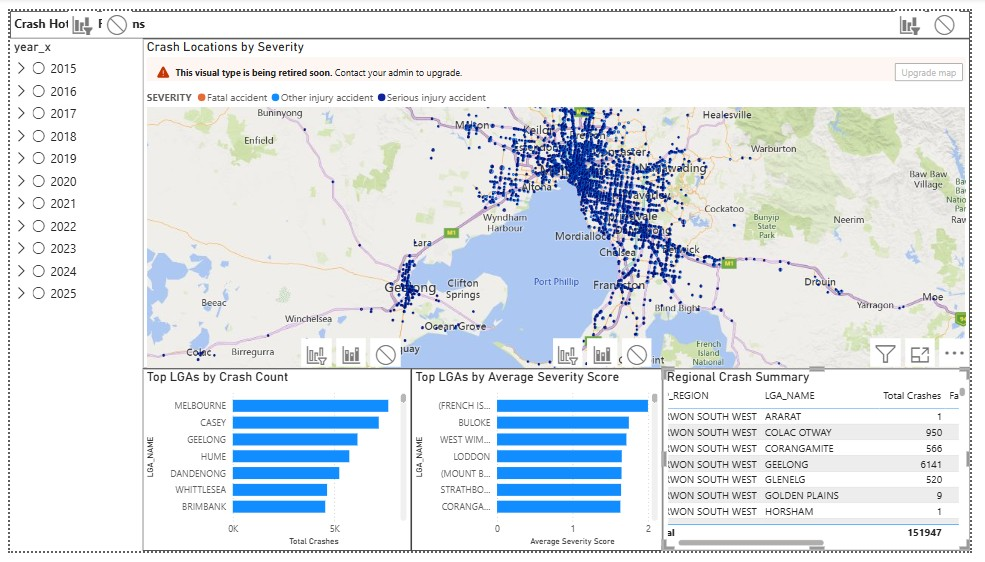

In [4]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/Hotspot Patterns.jpg"
display(Image(filename=image_path))

## Visual 3.1 Crash Locations by Severity

**Visual type:** Map  
**Columns/measures used:**

- `LATITUDE`
- `LONGITUDE`
- `SEVERITY`
- `ACCIDENT_NO or Total Crashes measure`

**Overview**

The map plots crash locations geographically and colours them by severity. This gives a spatial view of where recorded crashes are concentrated.

**Insights**

The crash points are strongly concentrated around the Melbourne metropolitan area, with additional clusters spreading into surrounding Victorian regions. This matches expectations because urban regions have greater traffic activity, more intersections and more road users.

**Relevance**

A map is one of the clearest visuals for road-safety communication because it immediately shows spatial concentration and supports hotspot identification.

## Visual 3.2 Top LGAs by Crash Count

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `LGA_NAME`
- `Total Crashes measure`

**Overview**

This chart ranks local government areas by total crash count.

**Insights**

The leading LGAs visible in the dashboard include **Melbourne**, **Casey**, **Geelong**, **Hume**, **Dandenong**, **Whittlesea** and **Brimbank**. These are areas with high traffic exposure, population activity, or major road networks.

**Relevance**

This visual identifies high-volume crash areas at an administrative level and supports targeted discussion around local road-safety planning.

## Visual 3.3 Top LGAs by Average Severity Score

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `LGA_NAME`
- `Average Severity Score measure`

**Overview**

This chart ranks LGAs by average severity rather than by crash count.

**Insights**

The output shows that some LGAs with fewer crashes can have higher average severity. Labels visible in the dashboard include smaller or regional areas such as French Island, Buloke, West Wimmera, Loddon, Mount Dandenong, Strathbogie and Corangamite.

**Relevance**

Crash count and average severity answer different questions. This view highlights places where crashes may be less frequent but more serious on average.

## Visual 3.4 Regional Crash Summary

**Visual type:** Table  
**Columns/measures used:**

- `DTP_REGION`
- `LGA_NAME`
- `Total Crashes measure`

**Overview**

The table provides a detailed summary of crash totals by region and LGA.

**Insights**

The table shows regional and LGA-level crash totals, with a total dashboard count of **151,947** visible in the output. It is useful for checking exact values that are not easy to read from the map or bar charts.

**Relevance**

Tables are useful when exact reporting values are needed. In this dashboard, the table acts as the detailed reference for the hotspot page.

# Page 4 Weather and Crash Insights

## Page purpose

The Weather and Crash Insights page examines how weather conditions relate to crash patterns. It includes temperature, rainfall, rain indicators, hot days, wind direction and the relationship between rainfall and crash severity.

**Main slicer used:** `year_x`  
**Main weather fields:** `Min temperature (°C)`, `Max temperature (°C)`, `Total Rainfall (mm)`, `rain_indicator`, `is_hot_day`, `Direction of wind`



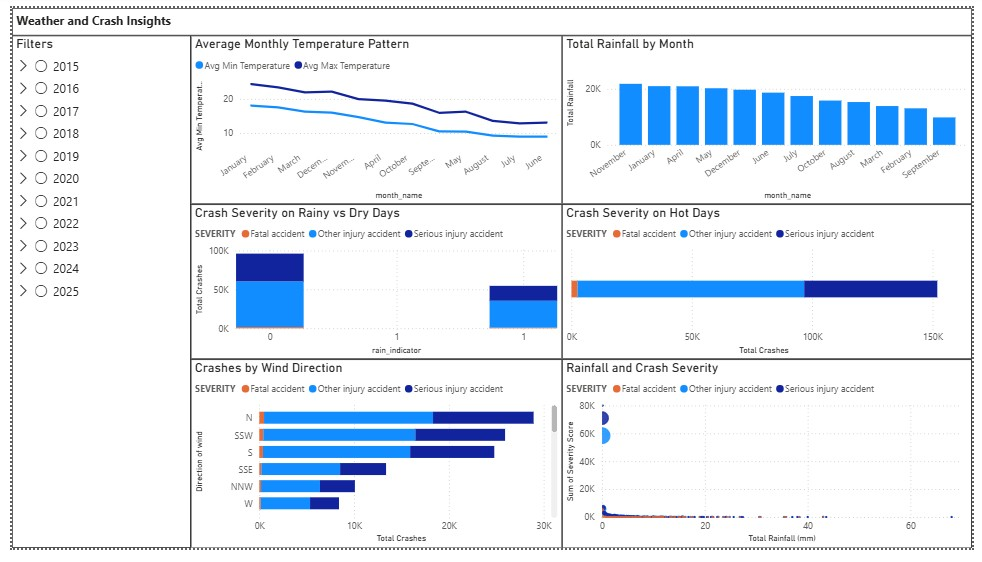

In [5]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/WeatherInsights.jpg"
display(Image(filename=image_path))

## Visual 4.1 Average Monthly Temperature Pattern

**Visual type:** Line chart  
**Columns/measures used:**

- `month_name`
- `Min temperature (°C)`
- `Max temperature (°C)`
- `Average Min Temperature measure`
- `Average Max Temperature measure`

**Overview**

This chart plots average minimum and maximum temperatures by month. The two lines make the monthly temperature pattern easy to compare.

**Insights**

The maximum-temperature line stays above the minimum-temperature line throughout the chart, which is expected. Warmer months show higher average values, while cooler months show lower values. This confirms that the weather features contain realistic seasonal variation.

**Relevance**

Temperature provides context for crash patterns and contributes to the integrated model features. This visual verifies that the weather data is interpretable and seasonally meaningful.

## Visual 4.2 Total Rainfall by Month

**Visual type:** Column chart  
**Columns/measures used:**

- `month_name`
- `Total Rainfall (mm)`
- `Total Rainfall measure`

**Overview**

This chart sums recorded rainfall by month and compares rainfall totals across the year.

**Insights**

The dashboard shows that some months have clearly higher rainfall totals than others. Months such as November, January, April, May, December, June and July appear among the larger rainfall totals, while September appears lower.

**Relevance**

Rainfall can influence road surface conditions and visibility. This visual provides weather context before comparing crashes on rainy and dry days.

## Visual 4.3 Crash Severity on Rainy vs Dry Days

**Visual type:** Stacked column chart  
**Columns/measures used:**

- `rain_indicator`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

This graph compares crash severity counts between dry days and rainy days. The `rain_indicator` variable separates days with measurable rainfall from non-rainy days.

**Insights**

Most crashes occur on days marked as non-rainy. This does not automatically mean dry weather is more dangerous; it may simply reflect that there are more dry days and more travel exposure under normal conditions.

**Relevance**

The visual helps keep the weather analysis balanced. Rainfall matters, but it should be interpreted alongside exposure, location, speed and road design.

## Visual 4.4 Crash Severity on Hot Days

**Visual type:** Stacked horizontal bar chart  
**Columns/measures used:**

- `is_hot_day`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

This visual compares crash severity under hot-day and non-hot-day conditions.

**Insights**

The output shows crash records associated with hot-day and non-hot-day conditions, with other injury and serious injury crashes forming most of the total. Fatal crashes remain a smaller segment.

**Relevance**

Hot weather may influence driving comfort, fatigue and travel patterns. This chart includes temperature-related risk context in the broader dashboard.

## Visual 4.5 Crashes by Wind Direction

**Visual type:** Stacked horizontal bar chart  
**Columns/measures used:**

- `Direction of wind`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

This chart compares crash counts by recorded wind direction. The original wind-direction category is used because it is more readable than the one-hot encoded wind columns.

**Insights**

The largest bars appear for directions such as **N**, **SSW** and **S**, with smaller totals for other directions. The stacked segments show that the broad severity pattern remains similar across directions.

**Relevance**

Wind direction is not as direct as rainfall or temperature, but it provides additional environmental context and shows how weather fields can be dashboarded clearly.

## Visual 4.6 Rainfall and Crash Severity

**Visual type:** Scatter plot  
**Columns/measures used:**

- `Total Rainfall (mm)`
- `Severity Score or severity-based measure`
- `SEVERITY`

**Overview**

This scatter plot compares rainfall amount with crash severity score.

**Insights**

Most points are concentrated near low rainfall values, suggesting that many crash records occur on days with little or no rainfall. A few high-rainfall outliers are present, but rainfall alone does not explain severity.

**Relevance**

The scatter plot prevents overinterpretation of rainfall totals. It shows that weather is part of the risk picture, not the only driver of crash severity.

# Page 5 Mobility Insights

## Page purpose

The Mobility Insights page examines how different road users and mobility-density variables relate to crash outcomes. It focuses on road-user involvement, pedestrian density, bicycle density and urban classification.

**Main slicer used:** `year_x`  
**Main mobility fields:** `PEDESTRIAN`, `BICYCLIST`, `MOTORCYCLIST`, `DRIVER`, `PASSENGER`, `pedestrian_density`, `bicycle_density`, `DEG_URBAN_NAME`



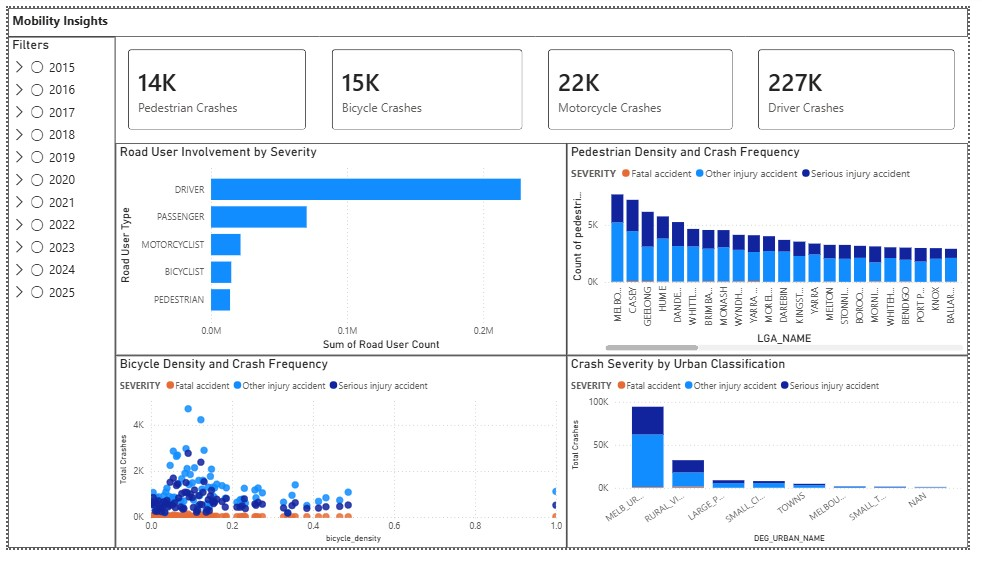

In [6]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/MobilityInsights.jpg"
display(Image(filename=image_path))

## Visual 5.1 Mobility KPI Cards

**Visual type:** KPI cards  
**Columns/measures used:**

- `PEDESTRIAN`
- `BICYCLIST`
- `MOTORCYCLIST`
- `DRIVER`
- `Sum-based road-user measures`

**Overview**

The KPI cards summarise road-user involvement totals.

**Insights**

The dashboard output shows approximately **14K** pedestrian records, **15K** bicycle records, **22K** motorcycle records and **227K** driver involvement records. Driver involvement is much higher, which is expected because most crashes involve at least one driver.

**Relevance**

These cards give a quick summary of road-user exposure before the viewer examines detailed road-user charts.

## Visual 5.2 Road User Involvement by Severity

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `Road User Type`
- `Road User Count`
- `SEVERITY`

**Overview**

This graph compares total involvement count for different road-user types. The original road-user columns were unpivoted into a long format so all user types could be shown in one chart.

**Insights**

The chart shows **Driver** as the largest category, followed by **Passenger**, **Motorcyclist**, **Bicyclist** and **Pedestrian**. This indicates that vehicle occupants dominate the crash records, while vulnerable road users form smaller but important groups.

**Relevance**

The visual makes road-user composition easier to read and helps separate general crash volume from vulnerable-road-user involvement.

## Visual 5.3 Pedestrian Density and Crash Frequency

**Visual type:** Bar chart by LGA  
**Columns/measures used:**

- `LGA_NAME`
- `pedestrian_density`
- `SEVERITY or Total Crashes measure`

**Overview**

This graph compares crash-frequency patterns across LGAs with pedestrian-density context.

**Insights**

Several urban LGAs appear prominently, including areas with high pedestrian activity. This is expected because pedestrian activity is usually linked with dense urban environments, busy intersections, retail areas and public transport access.

**Relevance**

Pedestrian density is an important mobility feature. This visual shows where pedestrian activity may overlap with crash concentration.

## Visual 5.4 Bicycle Density and Crash Frequency

**Visual type:** Scatter plot  
**Columns/measures used:**

- `bicycle_density`
- `Total Crashes measure`
- `SEVERITY`

**Overview**

The scatter plot compares bicycle density with crash frequency. Severity is used to distinguish the points.

**Insights**

Most points are concentrated at lower bicycle-density values, with some higher-density areas and outliers. The pattern is not purely linear, suggesting that road design, traffic volume and land-use context also matter.

**Relevance**

The visual shows that mobility density variables are useful, but they need to be interpreted with location and road-environment factors.

## Visual 5.5 Crash Severity by Urban Classification

**Visual type:** Stacked column chart  
**Columns/measures used:**

- `DEG_URBAN_NAME`
- `SEVERITY`
- `Total Crashes measure`

**Overview**

This chart compares crash severity across urban classification categories.

**Insights**

The largest crash count is shown for the **Melbourne urban** category, followed by regional or rural categories. This matches the broader dashboard pattern where metropolitan areas dominate crash volume.

**Relevance**

Urban classification helps distinguish dense urban crash patterns from regional or rural crash patterns.

# Page 6 Model Results

## Page purpose

The Model Results page summarises the modelling component of the project. It compares the baseline and advanced models, highlights the selected best model, shows class-wise performance and identifies the most important predictive features.

**Main model-output files used:**

- `all_model_comparison.csv`
- `advanced_classwise_performance.csv`
- `random_forest_feature_importance.csv`
- `xgboost_feature_importance.csv`



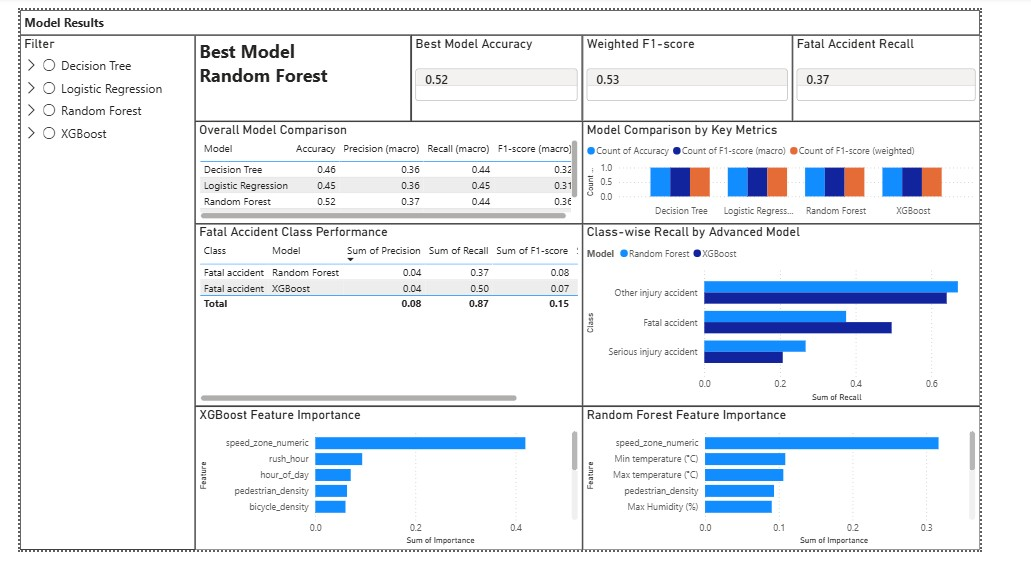

In [7]:
from IPython.display import Image, display

image_path = r"D:/Project/MOP-Code/Playground/BurhanT12026/notebook/images/ModelResult.jpg"
display(Image(filename=image_path))

## Model-output tables used in the dashboard

The following cell creates small model-output tables inside the notebook so the model results can be reviewed without relying on Power BI. These values are based on the model-output CSVs used for the final dashboard page.

In [8]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [0.451102, 0.459526, 0.518756, 0.480520],
    "Precision (macro)": [0.364228, 0.364736, 0.374305, 0.366265],
    "Recall (macro)": [0.449774, 0.442278, 0.437510, 0.447649],
    "F1-score (macro)": [0.314139, 0.323380, 0.357419, 0.332384],
    "F1-score (weighted)": [0.484276, 0.493191, 0.533743, 0.505370]
})

classwise_performance = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest", "Random Forest", "XGBoost", "XGBoost", "XGBoost"],
    "Class": ["Fatal accident", "Other injury accident", "Serious injury accident", "Fatal accident", "Other injury accident", "Serious injury accident"],
    "Precision": [0.044186, 0.668132, 0.410598, 0.038544, 0.669591, 0.390660],
    "Recall": [0.374753, 0.670048, 0.267728, 0.495069, 0.640569, 0.207308],
    "F1-score": [0.079051, 0.669089, 0.324117, 0.071520, 0.654759, 0.270874],
    "Support": [507, 18827, 11056, 507, 18827, 11056]
})

rf_importance = pd.DataFrame({
    "Feature": ["speed_zone_numeric", "Min temperature (°C)", "Max temperature (°C)", "pedestrian_density", "Max Humidity (%)"],
    "Importance": [0.316591, 0.108772, 0.106140, 0.093509, 0.090413]
})

xgb_importance = pd.DataFrame({
    "Feature": ["speed_zone_numeric", "rush_hour", "hour_of_day", "pedestrian_density", "bicycle_density"],
    "Importance": [0.419487, 0.093633, 0.070747, 0.063388, 0.060313]
})

model_comparison

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),F1-score (weighted)
0,Logistic Regression,0.451102,0.364228,0.449774,0.314139,0.484276
1,Decision Tree,0.459526,0.364736,0.442278,0.323380,0.493191
2,Random Forest,0.518756,0.374305,0.437510,0.357419,0.533743
3,XGBoost,0.480520,0.366265,0.447649,0.332384,0.505370


## Visual 6.1 Best Model KPI Cards

**Visual type:** KPI cards  
**Columns/measures used:**

- `Model`
- `Accuracy`
- `F1-score (weighted)`
- `Fatal accident recall from class-wise performance`

**Overview**

The KPI cards summarise the key modelling result at the top of the page.

**Insights**

The selected best model is **Random Forest**, with dashboard values around **0.52** accuracy, **0.53** weighted F1-score and **0.37** fatal accident recall. Random Forest was selected because it produced the strongest overall balance across the evaluated metrics.

**Relevance**

The KPI row gives the audience the model outcome immediately and keeps the page focused on the most important performance numbers.

## Visual 6.2 Overall Model Comparison

**Visual type:** Table  
**Columns/measures used:**

- `Model`
- `Accuracy`
- `Precision (macro)`
- `Recall (macro)`
- `F1-score (macro)`

**Overview**

The table lists each model and its evaluation metrics. It compares Logistic Regression, Decision Tree, Random Forest and XGBoost.

**Insights**

Random Forest achieves the highest overall accuracy at approximately **0.519** and the strongest weighted F1-score at approximately **0.534**. XGBoost is the next strongest overall model, with an accuracy of approximately **0.481**.

**Relevance**

The table shows exact values and provides evidence for selecting Random Forest as the final model.

## Visual 6.3 Model Comparison by Key Metrics

**Visual type:** Clustered column chart  
**Columns/measures used:**

- `Model`
- `Accuracy`
- `F1-score (macro)`
- `F1-score (weighted)`

**Overview**

This chart compares the main model metrics visually across all models.

**Insights**

Random Forest performs best overall across the key metrics used for selection. XGBoost remains competitive, but Random Forest has the strongest weighted performance.

**Relevance**

This visual is helpful in presentations because the relative performance of each model can be understood quickly.

## Visual 6.4 Fatal Accident Class Performance

**Visual type:** Table  
**Columns/measures used:**

- `Model`
- `Class`
- `Precision`
- `Recall`
- `F1-score`
- `Support`

**Overview**

This table focuses specifically on the fatal accident class for the advanced models.

**Insights**

XGBoost has higher fatal accident recall than Random Forest, at approximately **0.50** compared with **0.37**. Both models have low precision for fatal accidents and the support count for fatal accidents is only **507**, much smaller than the other classes.

**Relevance**

A model can perform reasonably overall while still struggling with the rarest class. This table makes that limitation clear.

## Visual 6.5 Class-wise Recall by Advanced Model

**Visual type:** Clustered bar chart  
**Columns/measures used:**

- `Model`
- `Class`
- `Recall`

**Overview**

This chart compares recall across severity classes for Random Forest and XGBoost.

**Insights**

Both advanced models have higher recall for other injury accidents, while fatal and serious injury accidents are more difficult. XGBoost performs better on fatal accident recall, while Random Forest gives better overall balance across the dataset.

**Relevance**

Recall is important in safety work because it shows how many actual cases the model successfully identifies.

## Visual 6.6 XGBoost Feature Importance

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `Feature`
- `Importance`

**Overview**

This chart shows the most important predictors used by XGBoost.

**Insights**

The strongest XGBoost feature is **speed_zone_numeric**, followed by **rush_hour**, **hour_of_day**, **pedestrian_density** and **bicycle_density**. This indicates that road speed, time-based travel conditions and mobility exposure were influential in the advanced model.

**Relevance**

Feature importance helps explain model behaviour and connects the model back to meaningful road, time and mobility variables.

## Visual 6.7 Random Forest Feature Importance

**Visual type:** Horizontal bar chart  
**Columns/measures used:**

- `Feature`
- `Importance`

**Overview**

This chart shows the most important predictors used by the Random Forest model.

**Insights**

The strongest feature is **speed_zone_numeric**, followed by temperature, pedestrian density, humidity and other weather or mobility-related variables. This supports the project’s integration approach because weather and mobility features contribute alongside road-speed information.

**Relevance**

Random Forest was selected as the best overall model, so this feature-importance chart is especially useful for explaining the final model.

# Final Dashboard Interpretation

The Power BI dashboard provides a complete view of the Traffic Accident Risk Prediction project. The severity overview shows that crash volume is concentrated in major regions and common road environments. The hotspot page confirms the geographic concentration around metropolitan and high-activity LGAs. The weather page shows that rainfall, temperature, hot days and wind direction provide useful context but do not explain crash severity by themselves. The mobility page highlights the dominance of driver involvement while still showing the importance of vulnerable road users and density-based mobility variables.

The model page brings the analysis together by showing that Random Forest was the strongest overall model, while XGBoost performed better on fatal accident recall. This distinction is important: the best overall model is not always the best model for the rarest and most serious class. The feature-importance charts also show that speed zone, weather, time and mobility variables all contributed to the prediction task.

Overall, the dashboard is useful because it allows both technical and non-technical viewers to move from descriptive crash patterns to model-based prediction results in one place.

# Limitations and Future Improvements

The dashboard should be interpreted with a few limitations in mind:

- Crash volume is influenced by exposure. Areas with more traffic and people naturally produce more crash records.
- Fatal accidents are rare compared with other injury classes, making them harder for machine-learning models to predict accurately.
- Weather variables provide useful context, but crash severity is also shaped by road design, behaviour, traffic volume and enforcement factors.
- Some visuals depend on grouped fields and dashboard filters, so exact values may change when users interact with slicers.
- Future work could include model threshold tuning, class weighting, imbalance-handling techniques and richer road-environment variables.

Despite these limitations, the dashboard gives a clear and practical way to communicate the project’s data integration, exploratory analysis, hotspot review, mobility context and modelling outcomes.

# Summary

This dashboard summarises the Traffic Accident Risk Prediction project using the validated modelling dataset. It begins with the Executive Overview page, which presents headline crash totals, yearly trends, severity distribution, Time period patterns and weekday versus weekend comparisons. The report then moves into crash severity patterns, hotspot mapping, weather insights, mobility indicators and final model results. The dashboard shows that crash volume is concentrated in metropolitan and high-activity areas, while severity patterns vary across road geometry, speed zones and local areas. The weather and mobility pages provide additional context by showing rainfall, temperature, wind direction, road-user involvement and density-related factors. The model results page shows that Random Forest achieved the best overall performance, while XGBoost had stronger fatal accident recall. Feature importance results highlight speed zone, weather, mobility and time-related variables as useful predictors of crash severity.
